# DNA Fractal

23andMe genotypes drawn as Sierpiński triangles, one SNP per cell.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

import dna_fractal as dfr
from dna_fractal.plates import genome_plate, ibs_plate
from dna_fractal.typography import register_fonts

ROOT = Path.cwd().parent
DATA = ROOT / "data" / "corpasome"
FIGURES = ROOT / "figures"

%run ../scripts/fetch_corpasome.py

father: present
mother: present
daughter: present
son: present
aunt: present


## Data

The Corpas family released five 23andMe genotypes into the public domain ([Corpas et al., 2015](https://doi.org/10.1186/s12864-015-1973-7); [figshare](https://doi.org/10.6084/m9.figshare.4491215)). Each row is a SNP: its rsid, chromosome, position on GRCh37 and genotype call. The son was typed on an older chip with fewer SNPs.

In [2]:
ROLES = ["father", "mother", "daughter", "son", "aunt"]
people = {role: dfr.read_23andme(DATA / f"{role}.zip") for role in ROLES}

summary = {
    role: {
        "SNPs": len(df),
        "chromosome 1": (df["chromosome"] == "1").sum(),
        "no calls": (df["genotype"] == "--").sum(),
    }
    for role, df in people.items()
}
pd.DataFrame(summary).T

,SNPs,chromosome 1,no calls
father,960614,76909,3261
mother,960614,76909,4049
daughter,960614,76909,3604
son,574518,43734,950
aunt,960614,76909,3474


In [3]:
people["father"].head()

,rsid,chromosome,position,genotype
0,rs4477212,1,82154,AA
1,rs3094315,1,752566,AA
2,rs3131972,1,752721,GG
3,rs12124819,1,776546,--
4,rs11240777,1,798959,GG


## Layout

Cell *i* holds the *i*-th SNP by position. Each subdivision visits the top, bottom-left and bottom-right sub-triangles in turn, so neighbouring SNPs land in neighbouring cells. A level-*n* triangle has 3<sup>*n*</sup> cells; those after the last SNP are padding.

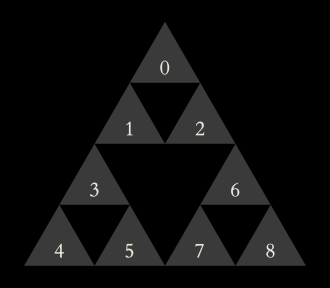

In [4]:
register_fonts()
cells = dfr.sierpinski_cells(2)
label = {"ha": "center", "va": "center", "family": "ETbb", "size": 15, "color": dfr.PLATE.ink}

fig, ax = plt.subplots(figsize=(4, 3.6), facecolor="black")
dfr.draw(ax, cells, ["#3a3a3a"] * len(cells), dfr.PLATE)
for i, (x, y) in enumerate(cells.mean(axis=1)):
    ax.text(x, y - 0.02, str(i), **label)
ax.set_aspect("equal")
ax.axis("off");

## Plate I

Chromosome 1 carries 76,909 SNPs on this chip, more than a level-10 triangle holds (59,049). Each arm gets its own triangle, split at the centromere: 1p upright, 1q inverted.

In [5]:
p, q = dfr.arms(people["father"], "1")
len(p), len(q)

(41269, 35640)

In [6]:
fig = genome_plate(people["father"], "1", "Corpas family  ·  father", "plate i")
fig.savefig(FIGURES / "plate_1.png", dpi=180, facecolor="black")
plt.close(fig)

![Plate I](../figures/plate_1.png)

## Identity by state

At each SNP two people share two, one or no alleles. A parent passes one allele at every site, so a parent and child always share at least one; zero between them is a genotyping error. Siblings, and unrelated people more often, can share none.

In [7]:
table = dfr.align({r: people[r] for r in ["father", "mother", "daughter", "aunt"]}, "1")
pairs = [
    ("father", "mother", "unrelated"),
    ("mother", "aunt", "sisters"),
    ("father", "daughter", "parent, child"),
    ("mother", "daughter", "parent, child"),
]

rows = {}
for a, b, relation in pairs:
    shared = dfr.ibs(table[a], table[b]).value_counts(normalize=True).sort_index()
    rows[f"{a} & {b}"] = {"relation": relation, **shared.round(4).to_dict()}
pd.DataFrame(rows).T

,relation,0,1,2
father & mother,unrelated,0.0544,0.3487,0.5969
mother & aunt,sisters,0.0134,0.2912,0.6954
father & daughter,"parent, child",0.0001,0.2821,0.7179
mother & daughter,"parent, child",0.0001,0.2824,0.7175


## Plate II

The same layout on 1q, coloured by alleles shared. The loupes look at the sub-triangle where the father and mother share none most often.

In [8]:
fig = ibs_plate(table, pairs, "1", "Corpas family", "plate ii")
fig.savefig(FIGURES / "plate_2.png", dpi=220, facecolor="black")
plt.close(fig)

![Plate II](../figures/plate_2.png)

## Mendelian errors

SNPs on chromosome 1 where the daughter's genotype cannot be formed from one allele of each parent: 16 of 76,529. In 13, she is homozygous for one parent's allele and the other parent is homozygous for a different one.

In [9]:
errors = dfr.mendelian_errors(table["daughter"], table["father"], table["mother"])
table[errors.fillna(False)][["position", "father", "mother", "daughter"]]

,position,father,mother,daughter
rsid,,,,
rs673451,5305364,GG,GG,GT
rs4846197,10282166,GG,AA,GG
rs2486674,28420384,AA,GG,AA
rs7664,47682017,GG,TT,GG
rs10782815,84126005,GG,AA,GG
rs7545959,96049429,TT,CC,TT
rs11165529,96443739,TT,TT,GT
rs7533102,107828950,TT,CC,TT
rs464218,109856306,GG,AA,GG
